# Handwritten Formula Recognition - Model Inference Notebook (`predict1.ipynb`)

This notebook performs inference on handwritten mathematical formula images using the trained **FormulaRecognizer** (EfficientNet-B0 Encoder + Transformer Decoder) model architecture created in `train1.ipynb`.

### Pipeline Overview:
1. **Environment & Device Selection**: Automated GPU/CPU verification.
2. **Vocabulary Setup**: Restores token mapping from `weights/vocab.pkl` or trained checkpoint.
3. **Model Architecture**: Replicates exact `Encoder`, `PositionalEncoding`, `Decoder`, and `FormulaRecognizer` classes matching `train1.ipynb`.
4. **Checkpoint Restoration**: Loads model weights from `weights/best_model.pth` (with fallback to `checkpoints/best_model.pth`).
5. **Image Preprocessing**: Aspect-ratio preserving `resize_with_padding` (128x512) and ImageNet normalization.
6. **Inference Algorithms**: Autoregressive **Greedy Search** and **Beam Search** with length penalty.
7. **Visualization**: Displays handwritten formula images alongside predicted LaTeX formulas.

In [11]:
# ==========================================================
# Cell 1 - Imports
# ==========================================================

import os
import math
import json
import pickle
import random
import warnings
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

warnings.filterwarnings('ignore')

In [12]:
# ==========================================================
# Cell 2 - Configuration & Device Setup
# ==========================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())
print("Inference Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU Device Name :", torch.cuda.get_device_name(0))
    print("Total VRAM      :", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2), "GB")
print("=" * 60)

PyTorch Version : 2.13.0+cpu
CUDA Available  : False
Inference Device: cpu


In [13]:
# ==========================================================
# Cell 3 - Hyperparameters (Matching train1.ipynb)
# ==========================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 512
EMBED_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 4
DROPOUT = 0.1
MAX_FORMULA_LENGTH = 128

In [14]:
# ==========================================================
# Cell 4 - Vocabulary Class & Loading
# ==========================================================

class Vocabulary:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.special_tokens = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
        self.token2idx = {}
        self.idx2token = {}

    def build(self, formulas):
        counter = Counter()
        for formula in formulas:
            tokens = formula.split()
            counter.update(tokens)
        vocab_tokens = [token for token, freq in counter.items() if freq >= self.min_freq]
        all_tokens = self.special_tokens + sorted(vocab_tokens)
        self.token2idx = {token: idx for idx, token in enumerate(all_tokens)}
        self.idx2token = {idx: token for token, idx in self.token2idx.items()}

    def encode(self, formula):
        tokens = formula.split()
        encoded = [self.token2idx["<SOS>"]]
        for token in tokens:
            encoded.append(self.token2idx.get(token, self.token2idx["<UNK>"]))
        encoded.append(self.token2idx["<EOS>"])
        return encoded

    def decode(self, indices):
        tokens = []
        for idx in indices:
            token = self.idx2token.get(idx, "<UNK>")
            if token == "<EOS>":
                break
            if token not in ["<SOS>", "<PAD>"]:
                tokens.append(token)
        return " ".join(tokens)

    def __len__(self):
        return len(self.token2idx)

# Attempt to load saved vocabulary
vocab = Vocabulary()
VOCAB_PATHS = ["weights/vocab.pkl", "weights/idx2token.json", "checkpoints/best_model.pth"]
loaded_vocab = False

if os.path.exists("weights/vocab.pkl"):
    with open("weights/vocab.pkl", "rb") as f:
        vocab = pickle.load(f)
    loaded_vocab = True
    print(f"✅ Vocabulary loaded from 'weights/vocab.pkl' (Size: {len(vocab)})")
elif os.path.exists("weights/idx2token.json"):
    with open("weights/idx2token.json", "r", encoding="utf-8") as f:
        idx2token = json.load(f)
    vocab.idx2token = {int(k): v for k, v in idx2token.items()}
    vocab.token2idx = {v: int(k) for k, v in idx2token.items()}
    loaded_vocab = True
    print(f"✅ Vocabulary loaded from 'weights/idx2token.json' (Size: {len(vocab)})")
elif os.path.exists("weights/best_model.pth"):
    checkpoint = torch.load("weights/best_model.pth", map_location="cpu", weights_only=False)
    if "vocab" in checkpoint:
        vocab = checkpoint["vocab"]
        loaded_vocab = True
        print(f"✅ Vocabulary loaded from model checkpoint (Size: {len(vocab)})")

if not loaded_vocab:
    print("⚠️ Warning: Vocabulary file not found! Please run train1.ipynb or verify weights directory.")

PAD_IDX = vocab.token2idx.get("<PAD>", 0)
SOS_IDX = vocab.token2idx.get("<SOS>", 1)
EOS_IDX = vocab.token2idx.get("<EOS>", 2)
UNK_IDX = vocab.token2idx.get("<UNK>", 3)

✅ Vocabulary loaded from 'weights/vocab.pkl' (Size: 241)


In [15]:
# ==========================================================
# Cell 5 - Model Architecture (Matching train1.ipynb)
# ==========================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(
            len(vocab),
            EMBED_DIM,
            padding_idx=PAD_IDX
        )
        self.position = PositionalEncoding(EMBED_DIM, DROPOUT)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=EMBED_DIM,
            nhead=NUM_HEADS,
            dim_feedforward=1024,
            dropout=DROPOUT,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=NUM_LAYERS
        )
        self.fc = nn.Linear(EMBED_DIM, len(vocab))

    def forward(self, memory, tgt, tgt_mask=None, tgt_padding_mask=None):
        tgt = self.embedding(tgt)
        tgt = self.position(tgt)
        out = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_padding_mask
        )
        return self.fc(out)

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((4, 16))
        self.projection = nn.Conv2d(1280, EMBED_DIM, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class FormulaRecognizer(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, images, tgt, tgt_mask=None, tgt_padding_mask=None):
        memory = self.encoder(images)
        return self.decoder(memory, tgt, tgt_mask, tgt_padding_mask)

def create_causal_mask(seq_len):
    mask = torch.triu(torch.ones(seq_len, seq_len, device=DEVICE), diagonal=1)
    return mask.masked_fill(mask == 1, float("-inf"))

print("✅ Model Architecture Defined Successfully!")

✅ Model Architecture Defined Successfully!


In [16]:
# ==========================================================
# Cell 6 - Load Best Trained Model Weights
# ==========================================================

CHECKPOINT_PATHS = [
    "weights/best_model.pth",
    "checkpoints/best_model.pth",
    "best_model.pth"
]

CHECKPOINT_PATH = next((p for p in CHECKPOINT_PATHS if os.path.exists(p)), "weights/best_model.pth")
model = FormulaRecognizer().to(DEVICE)

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print("=" * 60)
    print("✅ Best Model Loaded Successfully!")
    print(f"Checkpoint Path: {CHECKPOINT_PATH}")
    print(f"Epoch Trained  : {checkpoint.get('epoch', 'N/A') + 1 if isinstance(checkpoint.get('epoch'), int) else checkpoint.get('epoch', 'N/A')}")
    print(f"Best Val Loss  : {checkpoint.get('best_val_loss', 'N/A')}")
    print(f"Model Device   : {next(model.parameters()).device}")
    print("=" * 60)
else:
    print(f"⚠️ Warning: Checkpoint not found at '{CHECKPOINT_PATH}'!")

✅ Best Model Loaded Successfully!
Checkpoint Path: weights/best_model.pth
Epoch Trained  : 42
Best Val Loss  : 0.2293324842571448
Model Device   : cpu


In [18]:
# ==========================================================
# Cell 7 - Image Preprocessing Transform
# ==========================================================

def resize_with_padding(image, target_size=(512, 128)):
    """Resizes image keeping aspect ratio and pads to target_size (width, height)."""
    target_w, target_h = target_size
    w, h = image.size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
    image = image.resize((new_w, new_h), Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (target_w, target_h), (255, 255, 255))
    canvas.paste(image, ((target_w - new_w) // 2, (target_h - new_h) // 2))
    return canvas

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def preprocess_image(image_path):
    """Loads, resizes with aspect ratio padding, and converts image to tensor."""
    if isinstance(image_path, (str, Path)):
        image = Image.open(image_path).convert("RGB")
    elif isinstance(image_path, Image.Image):
        image = image_path.convert("RGB")
    else:
        raise ValueError("Unsupported image format")
    
    padded = resize_with_padding(image, (IMAGE_WIDTH, IMAGE_HEIGHT))
    tensor = eval_transform(padded).unsqueeze(0).to(DEVICE)
    return tensor, padded

In [19]:
# ==========================================================
# Cell 8 - Autoregressive Greedy Search Decoding
# ==========================================================

@torch.no_grad()
def predict_greedy(model, image_tensor, vocab, max_len=MAX_FORMULA_LENGTH):
    """Autoregressive Greedy Decoding for LaTeX formula recognition."""
    model.eval()
    memory = model.encoder(image_tensor)
    ys = torch.full((1, 1), SOS_IDX, dtype=torch.long, device=DEVICE)
    
    for _ in range(max_len - 1):
        tgt_mask = create_causal_mask(ys.size(1))
        out = model.decoder(memory, ys, tgt_mask=tgt_mask)
        next_word = out[:, -1, :].argmax(dim=-1).item()
        
        ys = torch.cat([ys, torch.full((1, 1), next_word, dtype=torch.long, device=DEVICE)], dim=1)
        if next_word == EOS_IDX:
            break
            
    pred_indices = ys.squeeze(0).tolist()
    return vocab.decode(pred_indices)

In [20]:
# ==========================================================
# Cell 9 - Beam Search Decoding
# ==========================================================

@torch.no_grad()
def predict_beam_search(model, image_tensor, vocab, beam_width=3, max_len=MAX_FORMULA_LENGTH, length_penalty=0.7):
    """Beam Search Decoding with length penalty for sequence prediction."""
    model.eval()
    memory = model.encoder(image_tensor)
    
    # Beam entry: (log_prob_score, sequence_tensor)
    beams = [(0.0, torch.full((1, 1), SOS_IDX, dtype=torch.long, device=DEVICE))]
    completed_beams = []
    
    for _ in range(max_len - 1):
        candidates = []
        for score, seq in beams:
            if seq[0, -1].item() == EOS_IDX:
                completed_beams.append((score, seq))
                continue
                
            tgt_mask = create_causal_mask(seq.size(1))
            out = model.decoder(memory, seq, tgt_mask=tgt_mask)
            log_probs = F.log_softmax(out[:, -1, :], dim=-1)
            topk_log_probs, topk_indices = log_probs.topk(beam_width, dim=-1)
            
            for i in range(beam_width):
                next_token = topk_indices[0, i].unsqueeze(0).unsqueeze(0)
                next_score = score + topk_log_probs[0, i].item()
                new_seq = torch.cat([seq, next_token], dim=1)
                candidates.append((next_score, new_seq))
                
        if not candidates:
            break
            
        # Sort candidates by normalized log probability
        candidates = sorted(candidates, key=lambda x: x[0] / (len(x[1][0]) ** length_penalty), reverse=True)
        beams = candidates[:beam_width]
        
    completed_beams.extend(beams)
    best_beam = max(completed_beams, key=lambda x: x[0] / (len(x[1][0]) ** length_penalty))
    pred_indices = best_beam[1].squeeze(0).tolist()
    return vocab.decode(pred_indices)

In [21]:
# ==========================================================
# Cell 10 - Single Image Prediction Function
# ==========================================================

def predict_formula(image_path, method="beam", beam_width=3):
    """
    Predicts LaTeX formula for a given image path.
    Methods: 'greedy' or 'beam'
    """
    image_tensor, original_img = preprocess_image(image_path)
    
    if method == "greedy":
        latex_pred = predict_greedy(model, image_tensor, vocab)
    else:
        latex_pred = predict_beam_search(model, image_tensor, vocab, beam_width=beam_width)
        
    return latex_pred, original_img

print("✅ Prediction Helper Ready!")

✅ Prediction Helper Ready!


Testing on sample image: dataset\HME100K\test\test_images\test_10.jpg


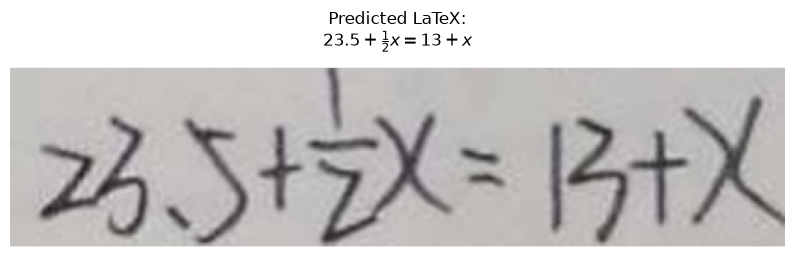

Predicted Formula Output:
2 3 . 5 + \frac { 1 } { 2 } x = 1 3 + x


In [ ]:
# ==========================================================
# Cell 11 - Demo Prediction on Sample Image
# ==========================================================

dataset_dir = Path("dataset/HME100K/test/test_images/")
sample_images = list(dataset_dir.glob("*.png")) + list(dataset_dir.glob("*.jpg"))

if sample_images:
    test_img_path = str(sample_images[0])
    print(f"Testing on sample image: {test_img_path}")
    
    formula, img = predict_formula(test_img_path, method="beam")
    
    plt.figure(figsize=(10, 3))
    plt.imshow(img)
    plt.title(f"Predicted LaTeX:\n${formula}$", fontsize=12, pad=10)
    plt.axis("off")
    plt.show()
    
    print("=" * 60)
    print("Predicted Formula Output:")
    print(formula)
    print("=" * 60)
else:
    print("No sample images found in dataset directory. Place test images in dataset/ to test predictions.")